# 04 — Baselines e Métricas de Ranking

Antes de treinar a rede neural (NCF), precisamos de uma **régua**: baselines
simples e um conjunto de métricas de ranking. Eles respondem à pergunta central
da entrega — *o modelo neural realmente supera abordagens triviais?*

**Protocolo de avaliação.** Para cada usuário do conjunto de validação
(`val_ground_truth` = o próximo pedido real), cada baseline produz um **ranking
de produtos**. Comparamos o *top-K* recomendado com os produtos efetivamente
comprados.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', 50)


def find_project_root(marker: str = 'pyproject.toml') -> Path:
    '''Sobe na arvore de diretorios ate encontrar o marcador do projeto.'''
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Marcador {marker} nao encontrado a partir de {current}')


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
IMG_DIR = PROJECT_ROOT / 'docs' / 'img' / 'baselines'
IMG_DIR.mkdir(parents=True, exist_ok=True)
print('Processed:', PROCESSED_DIR)

Processed: c:\Users\erick\projetos\mlp-market-recommender-system\data\processed


## 1. Carregar os dados

- `interactions` — histórico agregado (usado para construir os baselines).
- `val_ground_truth` — o próximo pedido real de cada usuário (o alvo da avaliação).

In [2]:
interactions = pd.read_parquet(PROCESSED_DIR / 'interactions.parquet')
val = pd.read_parquet(PROCESSED_DIR / 'val_ground_truth.parquet')

print('Interações :', f'{len(interactions):,}')
print('Validação  :', f'{len(val):,} linhas')
val.head()

Interações : 13,307,953
Validação  : 1,384,617 linhas


,user_id,product_id,reordered,user_idx,product_idx
0,112108,49302,1,112107,49291
1,112108,11109,1,112107,11105
2,112108,10246,0,112107,10242
3,112108,49683,0,112107,49671
4,112108,43633,1,112107,43625


## 2. Verdade-base (ground truth)

Agrupamos o próximo pedido de cada usuário em um **conjunto** de `product_idx`.
Descartamos itens *cold-start* (produtos sem índice — nunca vistos no histórico),
pois nenhum dos baselines consegue pontuá-los.

In [3]:
def build_ground_truth(val: pd.DataFrame) -> dict[int, set[int]]:
    '''Agrupa o proximo pedido de cada usuario em um conjunto de product_idx.'''
    valid = val.dropna(subset=['product_idx']).copy()
    valid['user_idx'] = valid['user_idx'].astype('int32')
    valid['product_idx'] = valid['product_idx'].astype('int32')
    grouped = valid.groupby('user_idx')['product_idx'].apply(set)
    return {int(user): set(map(int, items)) for user, items in grouped.items()}


ground_truth = build_ground_truth(val)
basket_sizes = np.array([len(items) for items in ground_truth.values()])
print('Usuários avaliados :', f'{len(ground_truth):,}')
print('Cesta média        :', f'{basket_sizes.mean():.1f} produtos')

Usuários avaliados : 131,209
Cesta média        : 10.6 produtos


## 3. Baseline A — Popularidade global

Recomenda os produtos mais comprados para **todos** os usuários, sem
personalização. É o piso: qualquer modelo "inteligente" precisa superá-lo.
Medimos popularidade pelo número de usuários distintos que compraram cada produto
(cada linha de `interactions` é um par único usuário–produto).

In [4]:
def rank_by_popularity(interactions: pd.DataFrame, top_n: int) -> np.ndarray:
    '''Ordena produtos pelo numero de usuarios distintos que os compraram.'''
    counts = interactions.groupby('product_idx').size().sort_values(ascending=False)
    return counts.index.to_numpy()[:top_n]


popular_items = rank_by_popularity(interactions, top_n=100)
pop_list = [int(item) for item in popular_items]
print('Top-10 produtos populares (product_idx):', pop_list[:10])

Top-10 produtos populares (product_idx): [24848, 13172, 21133, 21899, 47615, 26204, 47198, 16793, 47755, 39267]


## 4. Baseline B — Histórico do usuário

Para cada cliente, recomenda **os próprios produtos que ele mais compra**,
ordenados por frequência (`n_orders`). No Instacart, onde a maior parte do
pedido são recompras, este é um baseline forte — o verdadeiro alvo a superar.

In [5]:
def build_user_history(
    interactions: pd.DataFrame, eval_users: set[int], top_n: int
) -> dict[int, list[int]]:
    '''Ranqueia, por usuario, seus produtos por frequencia de compra (desc).'''
    subset = interactions[interactions['user_idx'].isin(eval_users)]
    ordered = subset.sort_values(['user_idx', 'n_orders'], ascending=[True, False])
    top = ordered.groupby('user_idx').head(top_n)
    grouped = top.groupby('user_idx')['product_idx'].apply(list)
    return {int(user): [int(p) for p in items] for user, items in grouped.items()}


user_history = build_user_history(interactions, set(ground_truth), top_n=100)
print('Usuários com histórico:', f'{len(user_history):,}')

Usuários com histórico: 131,209


## 5. Métricas de ranking

Quatro métricas complementares, todas avaliadas no *top-K*:

- **Precision@K** — dos K recomendados, quantos estavam no pedido real.
- **Recall@K** — do pedido real, quanto foi coberto pelos K recomendados.
- **NDCG@K** — premia acertos nas **primeiras** posições (desconto logarítmico).
- **MAP@K** — precisão média ao longo das posições em que houve acerto.

Precision/Recall ignoram a ordem; NDCG/MAP valorizam acertar no topo.

In [6]:
def precision_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Fracao dos k recomendados que estao no proximo pedido real.'''
    if k == 0:
        return 0.0
    hits = sum(1 for item in recs[:k] if item in truth)
    return hits / k


def recall_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Fracao do proximo pedido real coberta pelos k recomendados.'''
    if not truth:
        return 0.0
    hits = sum(1 for item in recs[:k] if item in truth)
    return hits / len(truth)


def ndcg_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Ganho cumulativo descontado normalizado: premia acertos no topo.'''
    dcg = sum(
        1.0 / np.log2(rank + 2)
        for rank, item in enumerate(recs[:k])
        if item in truth
    )
    ideal = sum(1.0 / np.log2(rank + 2) for rank in range(min(len(truth), k)))
    return dcg / ideal if ideal > 0 else 0.0


def average_precision_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Precisao media: media das precisoes nas posicoes em que houve acerto.'''
    if not truth:
        return 0.0
    score, hits = 0.0, 0
    for rank, item in enumerate(recs[:k]):
        if item in truth:
            hits += 1
            score += hits / (rank + 1)
    return score / min(len(truth), k)

## 6. Avaliação

`evaluate` recebe uma função de recomendação (`recommend_fn`) e aplica as quatro
métricas a todos os usuários, retornando a média. Esse desenho desacopla *como*
recomendamos de *como* medimos — qualquer modelo futuro (inclusive o NCF) entra
pela mesma porta. É um exemplo do princípio **aberto/fechado** (SOLID): aberto a
novos recomendadores, fechado a mudanças na avaliação.

In [7]:
METRICS = {
    'Precision@K': precision_at_k,
    'Recall@K': recall_at_k,
    'NDCG@K': ndcg_at_k,
    'MAP@K': average_precision_at_k,
}


def evaluate(recommend_fn, ground_truth: dict[int, set[int]], k: int) -> dict[str, float]:
    '''Media de cada metrica @k sobre todos os usuarios avaliados.'''
    totals = {name: 0.0 for name in METRICS}
    for user, truth in ground_truth.items():
        recs = recommend_fn(user)
        for name, metric_fn in METRICS.items():
            totals[name] += metric_fn(recs, truth, k)
    n_users = len(ground_truth)
    return {name: total / n_users for name, total in totals.items()}

Definimos as duas funções de recomendação e avaliamos em **K ∈ {5, 10, 20}**.
O baseline de histórico usa popularidade como *fallback* para usuários sem dados.

In [8]:
def recommend_popularity(user: int) -> list[int]:
    '''Recomendacao nao-personalizada: os produtos mais populares para todos.'''
    return pop_list


def recommend_history(user: int) -> list[int]:
    '''Recomendacao personalizada: o historico do usuario (fallback popularidade).'''
    return user_history.get(user, pop_list)


KS = [5, 10, 20]
baselines = {
    'Popularidade': recommend_popularity,
    'Histórico do usuário': recommend_history,
}

rows = []
for k in KS:
    for name, fn in baselines.items():
        scores = evaluate(fn, ground_truth, k)
        rows.append({'baseline': name, 'k': k, **scores})

results = pd.DataFrame(rows)
results

,baseline,k,Precision@K,Recall@K,NDCG@K,MAP@K
0,Popularidade,5,0.096059,0.047300,0.109838,0.061523
1,Histórico do usuário,5,0.343987,0.223340,0.405261,0.307396
2,Popularidade,10,0.072567,0.070053,0.097888,0.043979
3,Histórico do usuário,10,0.266606,0.318458,0.386368,0.261438
4,Popularidade,20,0.051428,0.094952,0.097310,0.038519
5,Histórico do usuário,20,0.191854,0.422896,0.401003,0.253861


## 7. Comparação visual (K = 10)

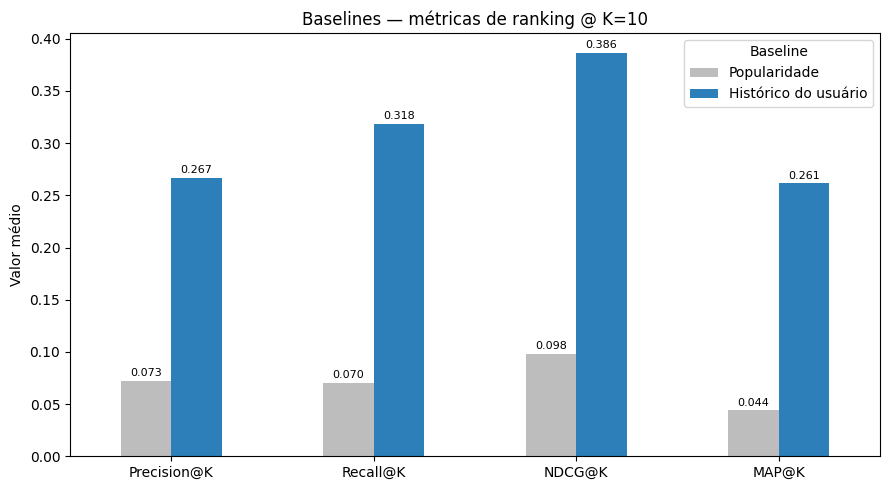

In [9]:
k = 10
metric_names = list(METRICS)
sub = results[results['k'] == k].set_index('baseline')[metric_names]

ax = sub.T.plot(kind='bar', figsize=(9, 5), color=['#bdbdbd', '#2c7fb8'])
ax.set_title(f'Baselines — métricas de ranking @ K={k}')
ax.set_ylabel('Valor médio')
ax.set_xlabel('')
ax.legend(title='Baseline')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(IMG_DIR / '01_baseline_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Salvar o artefato de métricas

In [10]:
metrics_path = PROCESSED_DIR / 'baseline_metrics.parquet'
results.to_parquet(metrics_path, index=False)
print(f'  saved {metrics_path.name}  ({len(results)} linhas)')
results[results['k'] == 10]

  saved baseline_metrics.parquet  (6 linhas)


,baseline,k,Precision@K,Recall@K,NDCG@K,MAP@K
2,Popularidade,10,0.072567,0.070053,0.097888,0.043979
3,Histórico do usuário,10,0.266606,0.318458,0.386368,0.261438


## 9. Resumo

- **Régua pronta:** quatro métricas de ranking (Precision, Recall, NDCG, MAP @K)
  e dois baselines (popularidade e histórico do usuário).
- A função `evaluate` aceita **qualquer** recomendador — o NCF será plugado nela
  sem mudar o código de avaliação.
- O baseline de **histórico** tende a dominar a popularidade: no Instacart, prever
  recompras já acerta boa parte do próximo pedido. Esse é o número que o NCF
  precisará superar.

**Próximo passo (`notebook 05`):** treinar a rede **NCF** (embeddings + MLP) com
*negative sampling* por época e *early stopping*, e plugá-la nesta mesma régua.